<a href="https://colab.research.google.com/github/leman-cap13/NLP_projects/blob/main/VisionTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q timm

In [2]:
%pip install -q --upgrade "fastai==2.8.8" timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 11.0 MB/s eta 0:00:00


In [3]:
from fastai.vision.all import *

import fastai
import fastcore
import fasttransform

print("fastai:", fastai.__version__)
print("fastcore:", fastcore.__version__)
print("fasttransform:", fasttransform.__version__)

fastai: 2.8.8
fastcore: 2.0.5
fasttransform: 0.0.2


In [4]:
import zipfile
from pathlib import Path

import requests
import torch
from tqdm.auto import tqdm

In [5]:

SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 32

FINE_TUNE_EPOCHS = 5

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

In [6]:
DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/908/realwaste.zip"
)

WORK_DIR = Path("/content/realwaste_project")
ZIP_PATH = WORK_DIR / "realwaste.zip"
EXTRACT_DIR = WORK_DIR / "extracted"
EXPORT_PATH = WORK_DIR / "vit_realwaste.pkl"

WORK_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED, reproducible=True)

print(
    "Device:",
    "GPU" if torch.cuda.is_available() else "CPU"
)

Device: GPU


In [7]:
if ZIP_PATH.exists() and not zipfile.is_zipfile(ZIP_PATH):
    print("Yarımçıq ZIP silinir...")
    ZIP_PATH.unlink()

if not ZIP_PATH.exists():

    print("Dataset endirilir...")

    response = requests.get(
        DATASET_URL,
        stream=True,
        timeout=60,
    )

    response.raise_for_status()

    total_size = int(
        response.headers.get("content-length", 0)
    )

    chunk_size = 1024 * 1024  # 1 MB

    with open(ZIP_PATH, "wb") as file:

        with tqdm(
            total=total_size if total_size > 0 else None,
            unit="B",
            unit_scale=True,
            desc="realwaste.zip",
        ) as progress:

            for chunk in response.iter_content(
                chunk_size=chunk_size
            ):
                if chunk:
                    file.write(chunk)
                    progress.update(len(chunk))

    print("Dataset endirildi.")

else:
    print("Dataset ZIP artıq mövcuddur.")

Dataset endirilir...


realwaste.zip: 0.00B [00:00, ?B/s]

Dataset endirildi.


In [8]:
dataset_candidates = [
    folder
    for folder in EXTRACT_DIR.rglob("RealWaste")
    if folder.is_dir()
]

if not dataset_candidates:

    print("Dataset extract olunur...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(EXTRACT_DIR)

    dataset_candidates = [
        folder
        for folder in EXTRACT_DIR.rglob("RealWaste")
        if folder.is_dir()
    ]

if not dataset_candidates:
    raise FileNotFoundError(
        "RealWaste dataset qovluğu tapılmadı."
    )

DATASET_DIR = dataset_candidates[0]

print("Dataset path:", DATASET_DIR)

Dataset extract olunur...
Dataset path: /content/realwaste_project/extracted/realwaste-main/RealWaste


In [9]:
dls = ImageDataLoaders.from_folder(
    DATASET_DIR,

    valid_pct=0.20,
    seed=SEED,

    item_tfms=Resize(IMAGE_SIZE),

    batch_tfms=aug_transforms(
        size=IMAGE_SIZE,
        min_scale=0.8,
    ),

    bs=BATCH_SIZE,
)

In [10]:
print("\nClasses:", dls.vocab)
print("Class count:", len(dls.vocab))
print("Train images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))




Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class count: 9
Train images: 3802
Validation images: 950


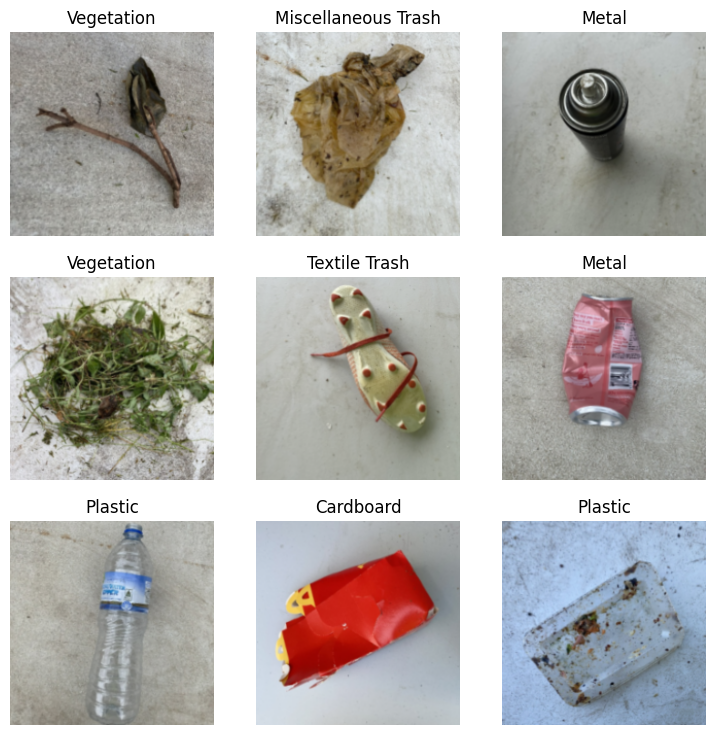

In [11]:
dls.show_batch(
    max_n=9,
    figsize=(9, 9),
)

In [12]:
learn = vision_learner(
    dls,

    # tiny   → kiçik ViT
    # patch16 → 16×16 patch
    # 224     → 224×224 input
    "vit_base_patch16_224",

    pretrained=True,

    metrics=[
        accuracy,
        F1Score(average="macro"),
    ],
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

In [13]:
if torch.cuda.is_available():
    learn = learn.to_fp16()


In [14]:
learn.fine_tune(
    FINE_TUNE_EPOCHS,
    freeze_epochs=1,
    base_lr=LEARNING_RATE,
    wd=WEIGHT_DECAY,
)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.155964,0.883400,0.700000,0.677905,00:40


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.145619,0.691674,0.774737,0.757292,00:49
1,0.831973,0.483667,0.828421,0.819967,00:51
2,0.598825,0.421136,0.850526,0.844985,00:56
3,0.482813,0.381402,0.867368,0.864058,00:49
4,0.438523,0.381194,0.870526,0.866296,00:49


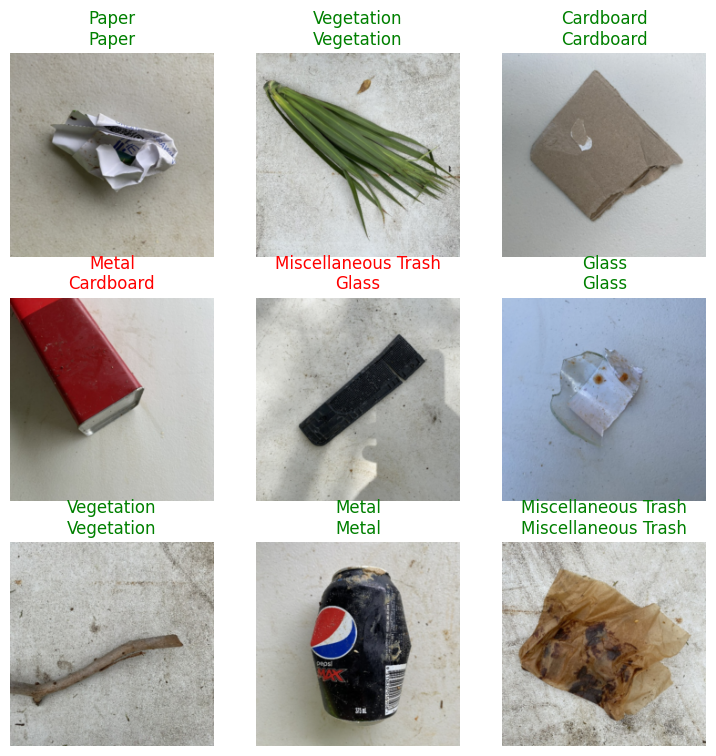

In [15]:
learn.show_results(
    max_n=9,
    figsize=(9, 9),
)

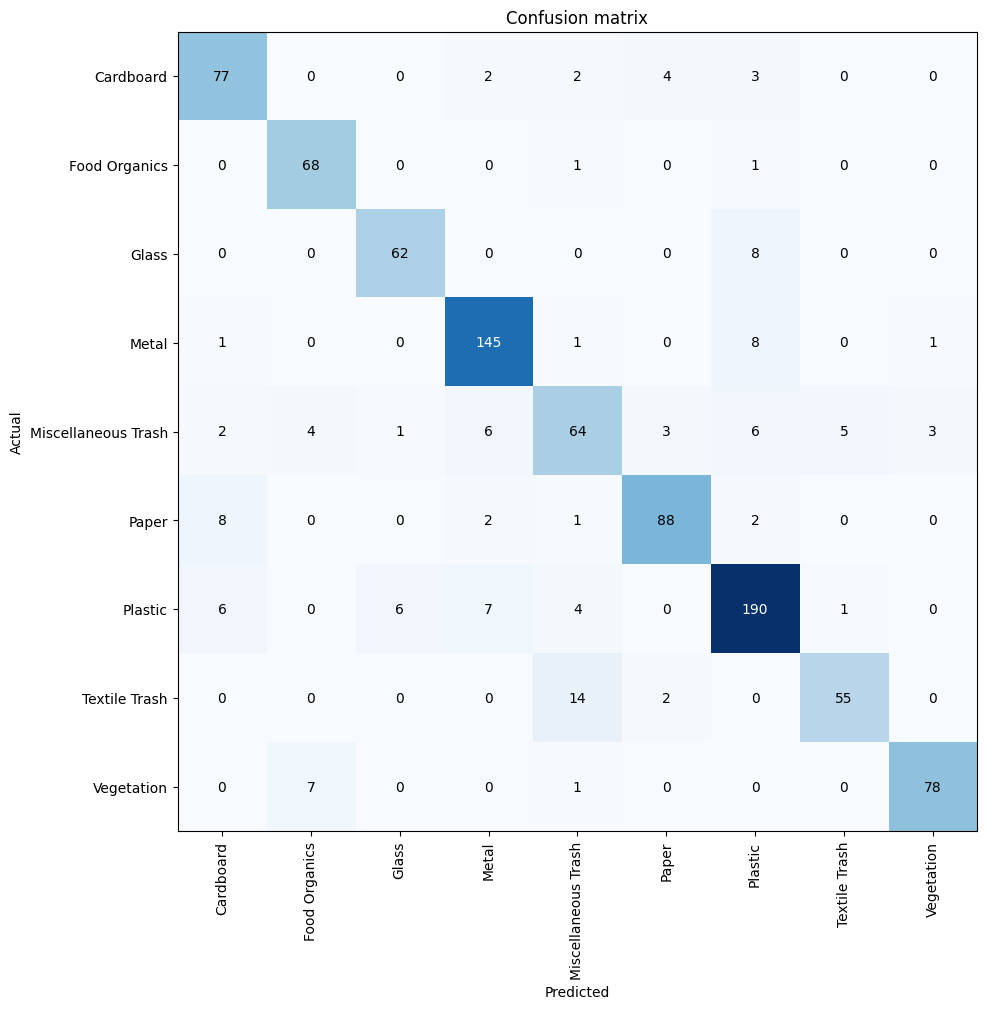

In [16]:
interp = ClassificationInterpretation.from_learner(
    learn
)

interp.plot_confusion_matrix(
    figsize=(10, 10),
)

In [17]:
learn.export(EXPORT_PATH)

print("\nProject completed.")
print("Model saved to:", EXPORT_PATH)


Project completed.
Model saved to: /content/realwaste_project/vit_realwaste.pkl
